In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
# Load Dataset
df = pd.read_csv(r"C:\Projects\Data Science\ipc-crime-data-analysis\data\districtwise-ipc-crimes-2017-onwards.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5322, 124)


,id,year,state_name,state_code,district_name,district_code,registration_circles,murder,clpbl_hmcrd_not_amt_murder,hit_and_run,...,ofnc_religion,cheating_impersonation,ofnc_mischief,arson,criminal_trespass,crlty_husbnd_relatives,crcl_false_fake_news_rumours,criminal_intimidation,insult_modesty_women,other_ipc_crimes
0,0,2017,Andhra Pradesh,28,Ananthapuramu,502,Anantapur,113.0,4.0,50.0,...,6.0,4.0,9.0,38.0,198.0,471.0,0.0,139.0,8.0,159.0
1,1,2017,Andhra Pradesh,28,Chittoor,503,Chittoor,70.0,5.0,36.0,...,0.0,0.0,4.0,7.0,100.0,212.0,1.0,26.0,12.0,470.0
2,2,2017,Andhra Pradesh,28,Y.S.R.,504,Cuddapah,88.0,10.0,32.0,...,0.0,1.0,44.0,68.0,198.0,481.0,0.0,332.0,60.0,447.0
3,3,2017,Andhra Pradesh,28,East Godavari,505,East Godavari,69.0,14.0,138.0,...,12.0,0.0,25.0,40.0,848.0,601.0,0.0,50.0,127.0,48.0
4,4,2017,Andhra Pradesh,28,Ananthapuramu,502,Guntakal Railway,11.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,4.0,6.0


In [3]:
# Dataset Overview

print("\nDataset Info:\n")
print(df.info())

print("\nDataset Description:\n")
print(df.describe().round(2))

print("\nColumns:\n", df.columns.tolist())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5322 entries, 0 to 5321
Columns: 124 entries, id to other_ipc_crimes
dtypes: float64(117), int64(4), object(3)
memory usage: 5.0+ MB
None

Dataset Description:

            id     year  state_code  district_code   murder  \
count  5322.00  5322.00     5322.00        5322.00  5322.00   
mean   2660.50  2019.56       17.72         367.00    32.61   
std    1536.47     1.71        9.89         386.28    30.21   
min       0.00  2017.00        1.00           1.00     0.00   
25%    1330.25  2018.00        9.00         171.00    10.00   
50%    2660.50  2020.00       19.00         356.00    27.00   
75%    3990.75  2021.00       24.00         536.75    46.00   
max    5321.00  2022.00       38.00        9999.00   318.00   

       clpbl_hmcrd_not_amt_murder  hit_and_run  acdnt_other_than_hit_and_run_  \
count                     5322.00      5322.00                        5322.00   
mean                         4.03        50

In [4]:
# Checking Missing Values

missing_values = df.isnull().sum().sort_values(ascending=False)

print("\nMissing Values per Column:")
print(missing_values[missing_values > 0])

print("\nTotal Missing Values:", df.isnull().sum().sum())


Missing Values per Column:
rioting_vigilants    3614
atmpt_acid_attack       1
dtype: int64

Total Missing Values: 3615


In [5]:
# Handling Missing Values

df = df.drop(['rioting_vigilants'], axis=1)

df['atmpt_acid_attack'] = df['atmpt_acid_attack'].fillna(
    df['atmpt_acid_attack'].median()
)

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows with negative values
num_cols = df.select_dtypes(include=[np.number]).columns
df = df[(df[num_cols] >= 0).all(axis=1)]

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (5322, 123)


In [6]:
# Feature Engineering: Total Crimes

crime_columns = df.select_dtypes(include=np.number).columns
crime_columns = crime_columns.drop(['id','year','state_code','district_code'])

df['total_crimes'] = df[crime_columns].sum(axis=1)

df[['state_name','district_name','year','total_crimes']].head()

,state_name,district_name,year,total_crimes
0,Andhra Pradesh,Ananthapuramu,2017,8119.0
1,Andhra Pradesh,Chittoor,2017,3804.0
2,Andhra Pradesh,Y.S.R.,2017,14502.0
3,Andhra Pradesh,East Godavari,2017,9041.0
4,Andhra Pradesh,Ananthapuramu,2017,751.0


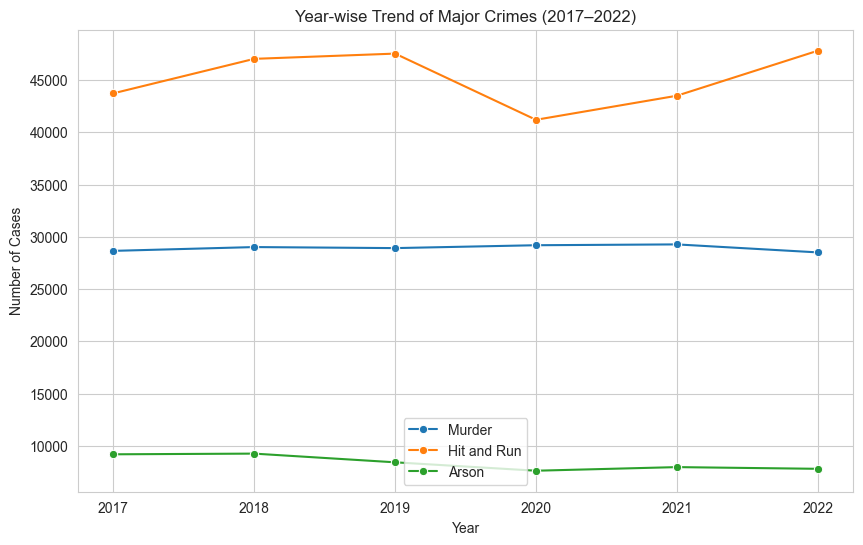

In [7]:
# Year-wise Trend of Major Crimes

yearly_trends = df.groupby('year')[['murder','hit_and_run','arson']].sum().reset_index()

plt.figure(figsize=(10,6))

sns.lineplot(data=yearly_trends, x="year", y="murder", marker='o', label='Murder')
sns.lineplot(data=yearly_trends, x="year", y="hit_and_run", marker='o', label='Hit and Run')
sns.lineplot(data=yearly_trends, x="year", y="arson", marker='o', label='Arson')

plt.title("Year-wise Trend of Major Crimes (2017–2022)")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.legend()
plt.show()

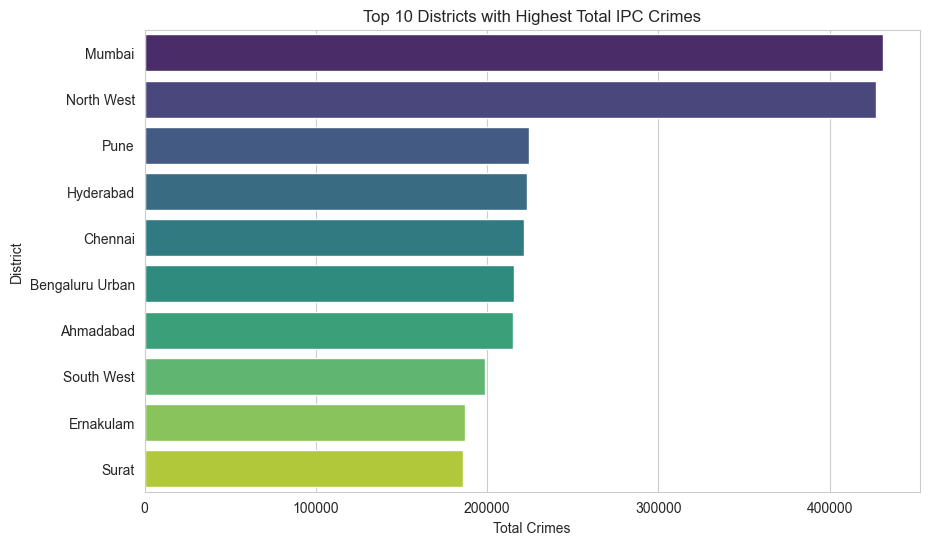

In [8]:
# Top 10 Districts with Highest Crimes

top_districts = (
    df.groupby('district_name')['total_crimes']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_districts.values,
    y=top_districts.index,
    hue=top_districts.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Districts with Highest Total IPC Crimes")
plt.xlabel("Total Crimes")
plt.ylabel("District")
plt.show()

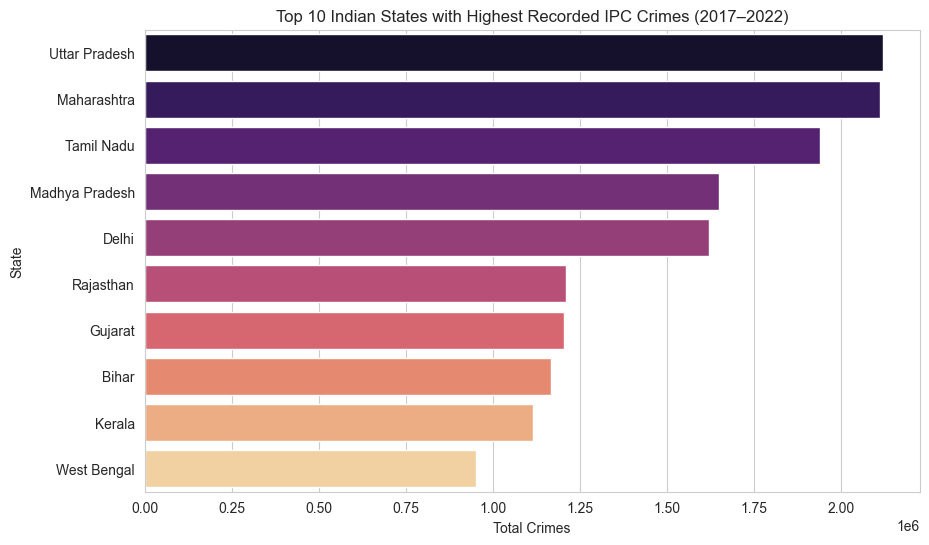

In [9]:
# Top 10 States with Highest Crimes

top_states = (
    df.groupby('state_name')['total_crimes']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index,
    hue=top_states.index,
    palette="magma",
    legend=False
)
plt.title("Top 10 Indian States with Highest Recorded IPC Crimes (2017–2022)")
plt.xlabel("Total Crimes")
plt.ylabel("State")
plt.show()

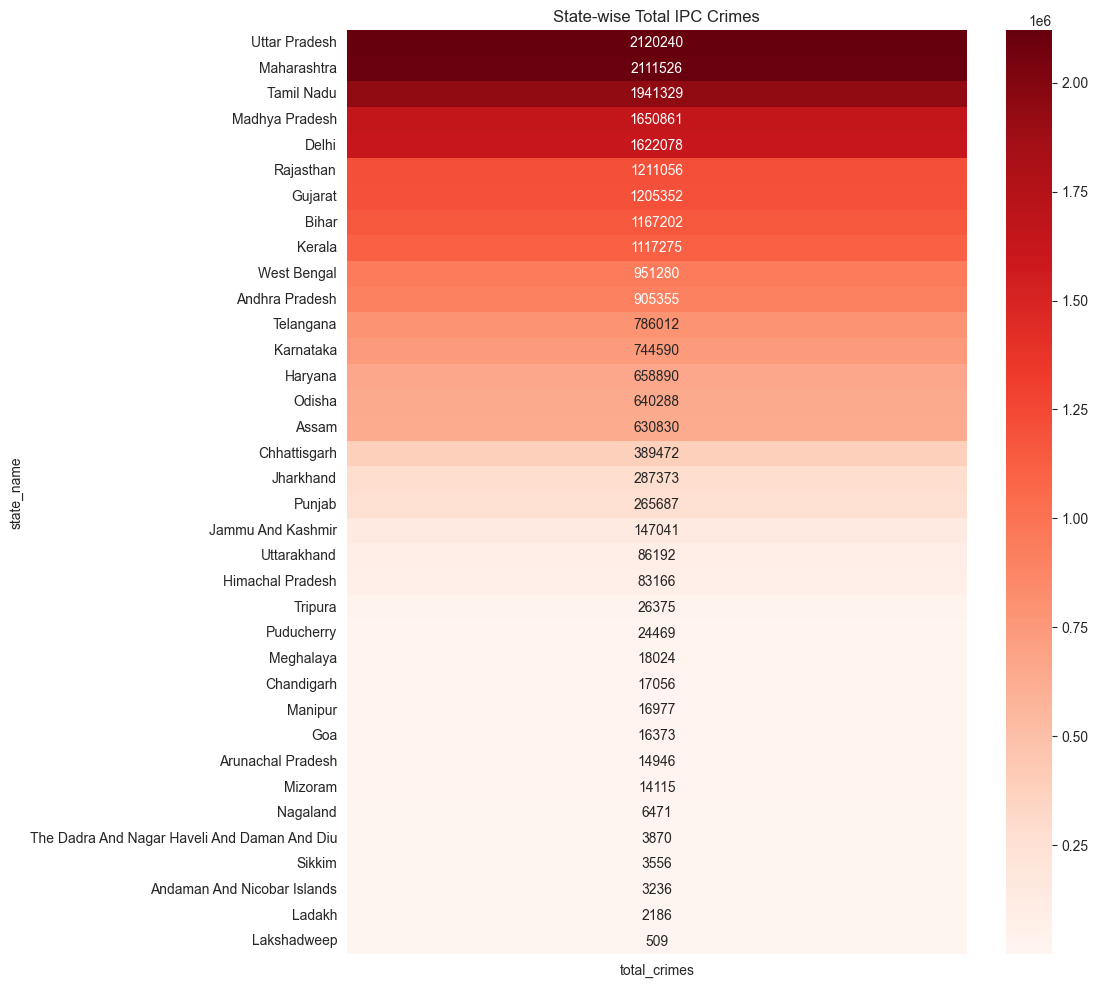

In [10]:
# State-wise Crime Heatmap

state_crimes = (
    df.groupby('state_name')['total_crimes']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,12))

sns.heatmap(
    state_crimes.to_frame(),
    annot=True,
    fmt=".0f",
    cmap="Reds"
)

plt.title("State-wise Total IPC Crimes")
plt.show()

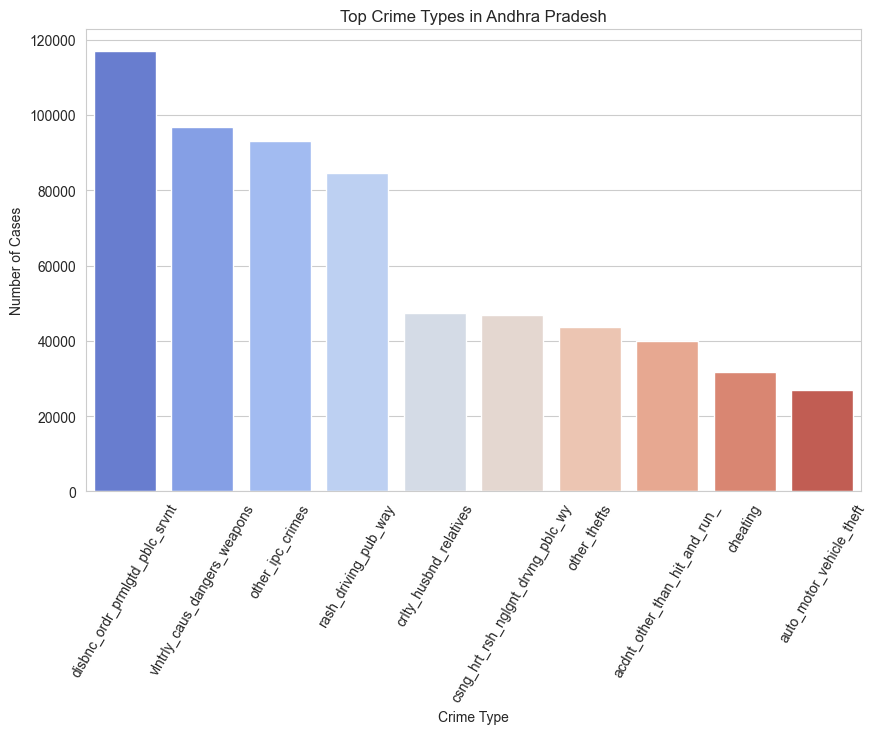

In [11]:
# Crime Distribution in a Selected State

state = "Andhra Pradesh"

state_data = df[df['state_name'] == state]

crime_distribution = (
    state_data[crime_columns]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

crime_df = crime_distribution.reset_index()
crime_df.columns = ['Crime_Type','Cases']

plt.figure(figsize=(10,6))

sns.barplot(
    x='Crime_Type',
    y='Cases',
    hue='Crime_Type',
    data=crime_df,
    palette='coolwarm',
    legend=False
)

plt.title(f"Top Crime Types in {state}")
plt.xticks(rotation=60)
plt.ylabel("Number of Cases")
plt.xlabel("Crime Type")

plt.show()

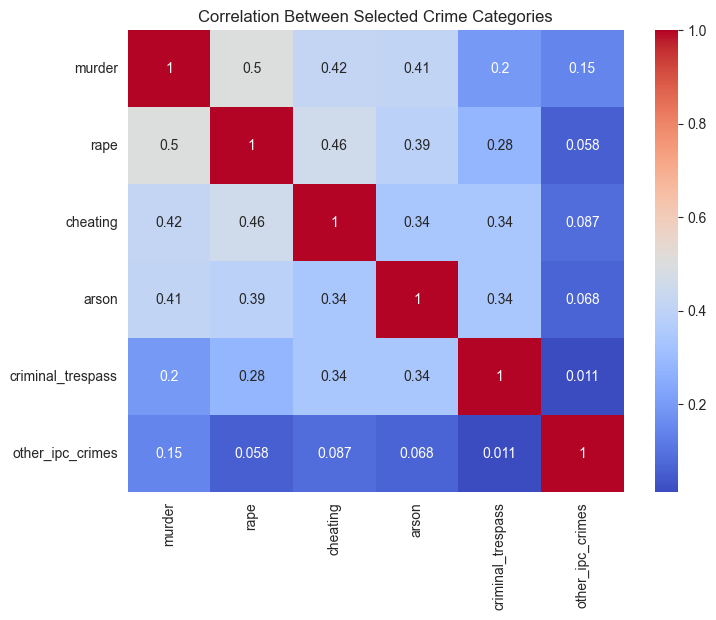

In [12]:
# Correlation Between Crime Categories

selected_columns = [
    'murder',
    'rape',
    'cheating',
    'arson',
    'criminal_trespass',
    'other_ipc_crimes'
]

correlation_matrix = df[selected_columns].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Between Selected Crime Categories")

plt.show()

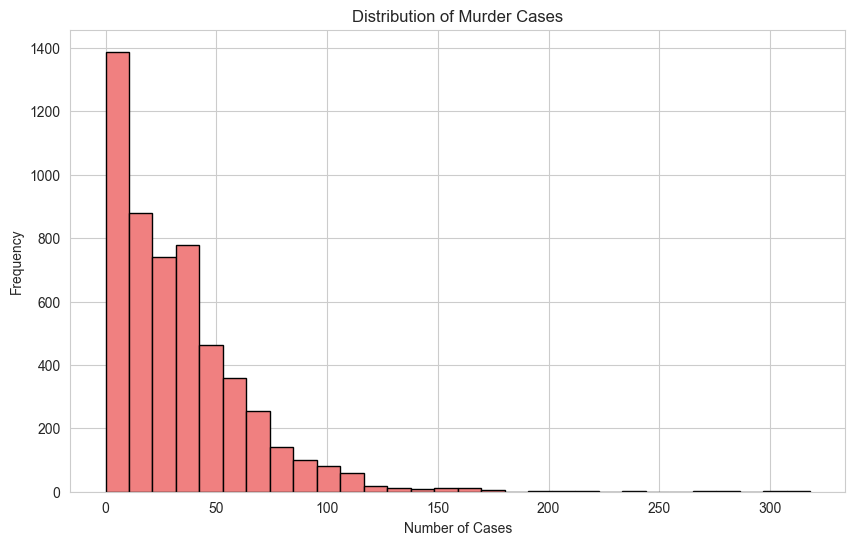

In [13]:
# Distribution of Murder Cases

plt.figure(figsize=(10,6))

df['murder'].hist(
    bins=30,
    color='lightcoral',
    edgecolor='black'
)

plt.title('Distribution of Murder Cases')
plt.xlabel('Number of Cases')
plt.ylabel('Frequency')

plt.show()

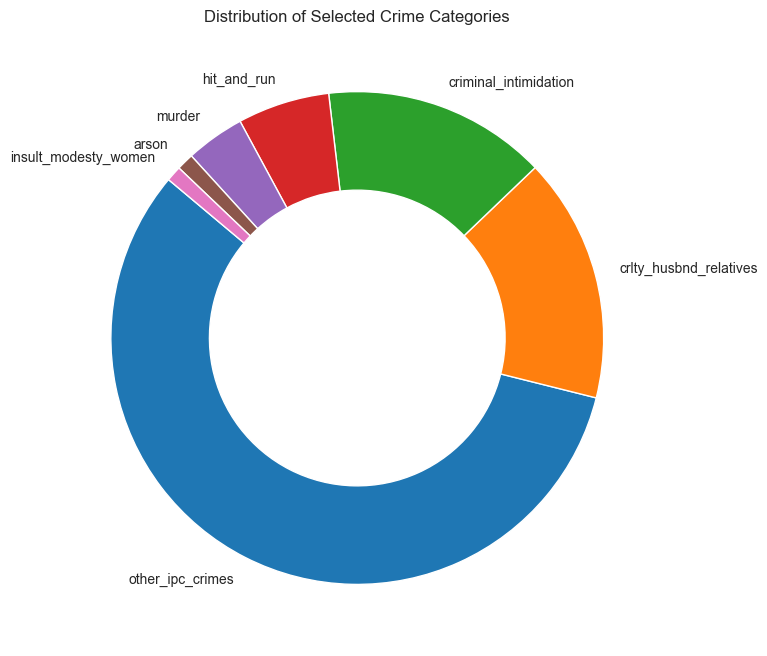

In [14]:
# Crime Category Distribution

crime_types = [
    'murder',
    'arson',
    'hit_and_run',
    'criminal_intimidation',
    'insult_modesty_women',
    'crlty_husbnd_relatives',
    'other_ipc_crimes'
]

category_totals = df[crime_types].sum().sort_values(ascending=False)

plt.figure(figsize=(8,8))

plt.pie(
    category_totals,
    labels=category_totals.index,
    startangle=140,
    wedgeprops=dict(width=0.4)
)

plt.title('Distribution of Selected Crime Categories')

plt.show()